# Continuous-Learning Menstruation Predictor (Prototype)

This notebook trains a small neural model to predict the **next period start** using only the last few **period start/end dates**.

**Important note about dates in this dataset**
- The CSV does not contain real calendar dates.
- It *does* contain `LengthofCycle` (days from one period start to the next) and `LengthofMenses` (bleeding duration).
- We reconstruct **relative** start/end day indices per client:
  - `start_day[1] = 0`
  - `start_day[i+1] = start_day[i] + LengthofCycle[i]`
  - `end_day[i] = start_day[i] + LengthofMenses[i]`

That gives us the same information as actual dates up to an arbitrary offset, which is sufficient for learning a predictor.

In [1]:
import os
import math
import random
from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch:", torch.__version__)
print("device:", device)
if device.type == "cuda":
    print("gpu:", torch.cuda.get_device_name(0))

torch: 2.10.0+cu128
device: cuda
gpu: NVIDIA GeForce RTX 4070


In [2]:
DATA_PATH = "dataset_mapped_filled_deduped.csv"  # produced earlier

def normalize_columns(cols: List[str]) -> List[str]:
    out = []
    for c in cols:
        if c is None:
            out.append(c)
        else:
            out.append(str(c).lstrip("\ufeff").strip())
    return out


df = pd.read_csv(DATA_PATH)
df.columns = normalize_columns(list(df.columns))
# Drop completely empty unnamed columns (your CSV has trailing commas)
df = df.loc[:, [c for c in df.columns if c and not str(c).lower().startswith("unnamed")]]

# Basic type cleanup
for col in ["ClientID", "CycleNumber", "LengthofCycle", "LengthofMenses"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["ClientID", "CycleNumber", "LengthofCycle", "LengthofMenses"]).copy()
df["ClientID"] = df["ClientID"].astype(int)
df["CycleNumber"] = df["CycleNumber"].astype(int)

# Keep only plausible rows
df = df[(df["LengthofCycle"] > 0) & (df["LengthofCycle"] < 120)]
df = df[(df["LengthofMenses"] > 0) & (df["LengthofMenses"] < 30)]

print("rows:", len(df))
print("clients:", df["ClientID"].nunique())
df.head()

rows: 1646
clients: 159


,ClientID,CycleNumber,ReproductiveCategory,LengthofCycle,LengthofMenses,MensesScoreDayOne,MensesScoreDayTwo,MensesScoreDayThree,MensesScoreDayFour,MensesScoreDayFive,...,Schoolyears,IncomeM,Height,Weight,Livingkids,Miscarriages,Abortions,Medvits,Breastfeeding,BMI
0,1,1,0,29,5.0,3,3,2,1,1,...,8,5,63,120,3,0,0,0,0,21.254724111867
1,1,2,0,27,5.0,3,3,2,1,1,...,8,5,63,120,3,0,0,0,0,21.254724111867
2,1,3,0,29,5.0,3,3,2,1,1,...,8,5,63,120,3,0,0,0,0,21.254724111867
3,1,4,0,27,5.0,3,3,3,2,1,...,8,5,63,120,3,0,0,0,0,21.254724111867
4,1,5,0,28,5.0,3,3,2,2,1,...,8,5,63,120,3,0,0,0,0,21.254724111867


In [3]:
# Build per-client relative start/end day indices
# start_day[cycle1]=0, start_day[next]=start_day+LengthofCycle

df = df.sort_values(["ClientID", "CycleNumber"]).reset_index(drop=True)

starts = []
ends = []

for client_id, g in df.groupby("ClientID", sort=False):
    g = g.sort_values("CycleNumber")
    cycle_len = g["LengthofCycle"].to_numpy(dtype=np.float32)
    menses_len = g["LengthofMenses"].to_numpy(dtype=np.float32)

    # start[0]=0; start[i] = sum_{j< i} cycle_len[j]
    start = np.concatenate([[0.0], np.cumsum(cycle_len[:-1])])
    end = start + menses_len

    starts.append(pd.Series(start, index=g.index))
    ends.append(pd.Series(end, index=g.index))


df["start_day"] = pd.concat(starts).sort_index().to_numpy(dtype=np.float32)
df["end_day"] = pd.concat(ends).sort_index().to_numpy(dtype=np.float32)

# Sanity: end >= start
assert (df["end_day"] >= df["start_day"]).all()

df[["ClientID", "CycleNumber", "LengthofCycle", "LengthofMenses", "start_day", "end_day"]].head(10)

,ClientID,CycleNumber,LengthofCycle,LengthofMenses,start_day,end_day
0,1,1,29,5.0,0.0,5.0
1,1,2,27,5.0,29.0,34.0
2,1,3,29,5.0,56.0,61.0
3,1,4,27,5.0,85.0,90.0
4,1,5,28,5.0,112.0,117.0
5,1,6,26,5.0,140.0,145.0
6,1,7,29,5.0,166.0,171.0
7,1,8,24,4.0,195.0,199.0
8,1,9,28,6.0,219.0,225.0
9,1,10,28,5.0,247.0,252.0


In [4]:
@dataclass
class WindowConfig:
    window_k: int = 6  # last k cycles


def build_windows(df: pd.DataFrame, cfg: WindowConfig):
    """Create samples:

    Input: last k (start_day, end_day) pairs up to cycle i (inclusive), shifted by start_i.
    Target: next cycle length = start_{i+1} - start_i = LengthofCycle_i.

    This matches the use-case: after logging the start/end of the last few periods,
    predict when the next period will start.
    """

    X_list: List[np.ndarray] = []
    y_list: List[float] = []
    client_list: List[int] = []

    for client_id, g in df.groupby("ClientID", sort=False):
        g = g.sort_values("CycleNumber")

        starts = g["start_day"].to_numpy(dtype=np.float32)
        ends = g["end_day"].to_numpy(dtype=np.float32)
        target_len = g["LengthofCycle"].to_numpy(dtype=np.float32)

        n = len(g)
        # Need i+1 to exist, so i <= n-2
        for i in range(cfg.window_k - 1, n - 1):
            s_ref = starts[i]
            # window cycles: i-k+1 ... i
            s_win = starts[i - cfg.window_k + 1 : i + 1] - s_ref
            e_win = ends[i - cfg.window_k + 1 : i + 1] - s_ref

            # feature shape: (k, 2) -> flatten
            feats = np.stack([s_win, e_win], axis=1).reshape(-1)

            X_list.append(feats)
            y_list.append(float(target_len[i]))
            client_list.append(int(client_id))

    X = np.stack(X_list, axis=0).astype(np.float32)
    y = np.array(y_list, dtype=np.float32)
    clients = np.array(client_list, dtype=np.int64)
    return X, y, clients


cfg = WindowConfig(window_k=6)
X, y, clients = build_windows(df, cfg)
print("samples:", X.shape[0])
print("X shape:", X.shape, "(features=2*k)")
print("y shape:", y.shape)
print("unique clients in samples:", len(np.unique(clients)))
print("y stats (days):", {"mean": float(y.mean()), "std": float(y.std()), "min": float(y.min()), "max": float(y.max())})

samples: 850
X shape: (850, 12) (features=2*k)
y shape: (850,)
unique clients in samples: 106
y stats (days): {'mean': 29.061176300048828, 'std': 3.854228973388672, 'min': 18.0, 'max': 51.0}


In [5]:
# Train/test split by client (avoid leakage)
unique_clients = np.unique(clients)
rng = np.random.default_rng(SEED)
rng.shuffle(unique_clients)

n_total = len(unique_clients)
n_train = int(0.8 * n_total)
train_clients = set(unique_clients[:n_train])
test_clients = set(unique_clients[n_train:])

train_mask = np.array([c in train_clients for c in clients])
test_mask = np.array([c in test_clients for c in clients])

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

print("clients (train/test):", len(train_clients), len(test_clients))
print("samples (train/test):", len(X_train), len(X_test))

# Feature scaling (z-score) using train only
mu = X_train.mean(axis=0, keepdims=True)
sigma = X_train.std(axis=0, keepdims=True) + 1e-6

X_train_s = (X_train - mu) / sigma
X_test_s = (X_test - mu) / sigma

class NpDataset(Dataset):
    def __init__(self, X_np: np.ndarray, y_np: np.ndarray):
        self.X = torch.from_numpy(X_np).float()
        self.y = torch.from_numpy(y_np).float()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

batch_size = 256
train_loader = DataLoader(NpDataset(X_train_s, y_train), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(NpDataset(X_test_s, y_test), batch_size=batch_size, shuffle=False)

len(train_loader), len(test_loader)

clients (train/test): 84 22
samples (train/test): 708 142


(3, 1)

epoch 001 | train_loss=28.346
epoch 005 | train_loss=27.888
epoch 010 | train_loss=26.538
epoch 015 | train_loss=23.462
epoch 020 | train_loss=18.980
epoch 025 | train_loss=15.559
epoch 030 | train_loss=11.898
epoch 035 | train_loss=10.825
epoch 040 | train_loss=10.214
test: {'MAE_days': 11.239886283874512, 'RMSE_days': 12.657591798085177}


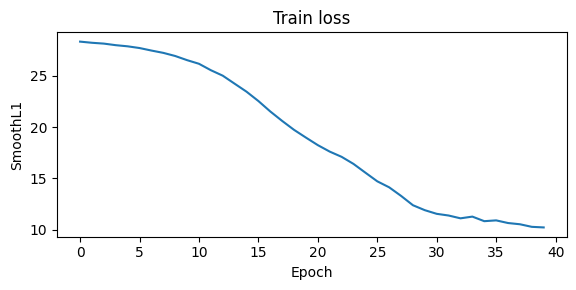

In [6]:
class PeriodMLP(nn.Module):
    def __init__(self, in_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def evaluate(model: nn.Module, loader: DataLoader) -> Dict[str, float]:
    model.eval()
    abs_err = []
    sq_err = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            pred = model(xb)
            err = pred - yb
            abs_err.append(err.abs().detach().cpu())
            sq_err.append((err ** 2).detach().cpu())
    abs_err = torch.cat(abs_err).numpy()
    sq_err = torch.cat(sq_err).numpy()
    return {
        "MAE_days": float(abs_err.mean()),
        "RMSE_days": float(math.sqrt(sq_err.mean())),
    }


def train(model: nn.Module, epochs: int = 40, lr: float = 2e-3):
    model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    loss_fn = nn.SmoothL1Loss()  # robust to outliers

    history = {"train_loss": []}

    for ep in range(1, epochs + 1):
        model.train()
        losses = []
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            opt.zero_grad(set_to_none=True)
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()
            losses.append(loss.detach().cpu().item())

        train_loss = float(np.mean(losses))
        history["train_loss"].append(train_loss)

        if ep == 1 or ep % 5 == 0:
            print(f"epoch {ep:03d} | train_loss={train_loss:.3f}")

    return history


in_dim = X_train_s.shape[1]
model = PeriodMLP(in_dim)
hist = train(model, epochs=40, lr=2e-3)

print("test:", evaluate(model, test_loader))

plt.figure(figsize=(6, 3))
plt.plot(hist["train_loss"])
plt.title("Train loss")
plt.xlabel("Epoch")
plt.ylabel("SmoothL1")
plt.tight_layout()
plt.show()

## Simple predictor: last 2 cycle lengths + age + BMI → next cycle interval

This section matches your desired “test case” inputs:
- last two cycle lengths (days)
- age (years)
- BMI

Target:
- next cycle length (days), reported as a predictive interval.

We train a small neural regressor that outputs a Gaussian distribution $(\mu, \sigma)$ over the next cycle length.

In [ ]:
def build_last2_age_bmi_samples(df: pd.DataFrame):
    df2 = df.copy()
    for col in ["ClientID", "CycleNumber", "LengthofCycle", "Age", "BMI"]:
        if col in df2.columns:
            df2[col] = pd.to_numeric(df2[col], errors="coerce")

    df2 = df2.dropna(subset=["ClientID", "CycleNumber", "LengthofCycle", "Age", "BMI"]).copy()
    df2["ClientID"] = df2["ClientID"].astype(int)
    df2["CycleNumber"] = df2["CycleNumber"].astype(int)

    df2 = df2.sort_values(["ClientID", "CycleNumber"]).reset_index(drop=True)

    X_list: List[np.ndarray] = []
    y_list: List[float] = []
    c_list: List[int] = []

    for client_id, g in df2.groupby("ClientID", sort=False):
        g = g.sort_values("CycleNumber")
        L = g["LengthofCycle"].to_numpy(dtype=np.float32)
        age = g["Age"].to_numpy(dtype=np.float32)
        bmi = g["BMI"].to_numpy(dtype=np.float32)

        n = len(g)
        # Need two previous lengths and a next target => i from 1..n-2
        for i in range(1, n - 1):
            x = np.array([L[i - 1], L[i], age[i], bmi[i]], dtype=np.float32)
            y_next = float(L[i + 1])
            X_list.append(x)
            y_list.append(y_next)
            c_list.append(int(client_id))

    X = np.stack(X_list, axis=0).astype(np.float32)
    y = np.array(y_list, dtype=np.float32)
    clients = np.array(c_list, dtype=np.int64)
    return X, y, clients


X2, y2, c2 = build_last2_age_bmi_samples(df)
print("samples:", X2.shape[0])
print("X2 shape:", X2.shape, "(features=[L_{t-1}, L_t, age, bmi])")
print("y2 stats:", {"mean": float(y2.mean()), "std": float(y2.std()), "min": float(y2.min()), "max": float(y2.max())})
print("clients:", len(np.unique(c2)))

In [ ]:
# 80/20 split by client
unique_clients2 = np.unique(c2)
rng = np.random.default_rng(SEED)
rng.shuffle(unique_clients2)

n_total2 = len(unique_clients2)
n_train2 = int(0.8 * n_total2)
train_clients2 = set(unique_clients2[:n_train2])
test_clients2 = set(unique_clients2[n_train2:])

train_mask2 = np.array([c in train_clients2 for c in c2])
test_mask2 = np.array([c in test_clients2 for c in c2])

X2_train, y2_train = X2[train_mask2], y2[train_mask2]
X2_test, y2_test = X2[test_mask2], y2[test_mask2]

print("clients (train/test):", len(train_clients2), len(test_clients2))
print("samples (train/test):", len(X2_train), len(X2_test))

# Scale features based on train split
mu2 = X2_train.mean(axis=0, keepdims=True)
sigma2 = X2_train.std(axis=0, keepdims=True) + 1e-6

X2_train_s = (X2_train - mu2) / sigma2
X2_test_s = (X2_test - mu2) / sigma2

train2_loader = DataLoader(NpDataset(X2_train_s, y2_train), batch_size=256, shuffle=True)
test2_loader = DataLoader(NpDataset(X2_test_s, y2_test), batch_size=512, shuffle=False)

len(train2_loader), len(test2_loader)

In [ ]:
class GaussianMLP(nn.Module):
    def __init__(self, in_dim: int):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(in_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 32),
            nn.ReLU(),
        )
        self.head = nn.Linear(32, 2)  # mean, raw_scale

    def forward(self, x):
        h = self.backbone(x)
        mean, raw_scale = self.head(h).chunk(2, dim=-1)
        mean = mean.squeeze(-1)
        # softplus keeps it positive; add epsilon for stability
        scale = torch.nn.functional.softplus(raw_scale.squeeze(-1)) + 1e-3
        return mean, scale


def gaussian_nll(mean: torch.Tensor, scale: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    # Negative log-likelihood of Normal(mean, scale)
    var = scale ** 2
    return 0.5 * (torch.log(2 * torch.tensor(math.pi, device=y.device)) + torch.log(var) + (y - mean) ** 2 / var).mean()


def evaluate_gaussian(model: nn.Module, loader: DataLoader, alpha: float = 0.1) -> Dict[str, float]:
    model.eval()
    abs_err = []
    sq_err = []
    cover = []

    z = torch.distributions.Normal(0.0, 1.0).icdf(
        torch.tensor([alpha / 2, 1 - alpha / 2], device=device)
    )

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            mean, scale = model(xb)

            err = mean - yb
            abs_err.append(err.abs().detach().cpu())
            sq_err.append((err ** 2).detach().cpu())

            lower = mean + scale * z[0]
            upper = mean + scale * z[1]
            cover.append(((yb >= lower) & (yb <= upper)).detach().cpu())

    abs_err = torch.cat(abs_err).numpy()
    sq_err = torch.cat(sq_err).numpy()
    cover = torch.cat(cover).numpy()

    return {
        "MAE_days": float(abs_err.mean()),
        "RMSE_days": float(math.sqrt(sq_err.mean())),
        f"PI{int((1-alpha)*100)}_coverage": float(cover.mean()),
    }


def train_gaussian(model: nn.Module, epochs: int = 60, lr: float = 2e-3):
    model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    history = {"train_nll": []}

    for ep in range(1, epochs + 1):
        model.train()
        losses = []
        for xb, yb in train2_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            opt.zero_grad(set_to_none=True)
            mean, scale = model(xb)
            loss = gaussian_nll(mean, scale, yb)
            loss.backward()
            opt.step()
            losses.append(loss.detach().cpu().item())

        train_loss = float(np.mean(losses))
        history["train_nll"].append(train_loss)

        if ep == 1 or ep % 10 == 0:
            print(f"epoch {ep:03d} | train_NLL={train_loss:.3f}")

    return history


gauss_model = GaussianMLP(in_dim=4)
train_hist2 = train_gaussian(gauss_model, epochs=60, lr=2e-3)

print("test metrics:", evaluate_gaussian(gauss_model, test2_loader, alpha=0.1))

plt.figure(figsize=(6, 3))
plt.plot(train_hist2["train_nll"])
plt.title("Train NLL")
plt.xlabel("Epoch")
plt.ylabel("NLL")
plt.tight_layout()
plt.show()

In [ ]:
def predict_next_cycle_interval(
    last_two_cycle_lengths: Tuple[float, float],
    age_years: float,
    bmi: float,
    *,
    alpha: float = 0.1,
) -> Dict[str, float]:
    """Predict next cycle length as an interval.

    Inputs:
      last_two_cycle_lengths: (L_{t-1}, L_t) in days
      age_years: age in years
      bmi: body-mass index
      alpha: 0.1 => 90% predictive interval

    Returns a dict with mean, std, lower, upper.
    """

    x = np.array([
        float(last_two_cycle_lengths[0]),
        float(last_two_cycle_lengths[1]),
        float(age_years),
        float(bmi),
    ], dtype=np.float32)[None, :]
    x_s = (x - mu2) / sigma2

    xb = torch.from_numpy(x_s).float().to(device)
    gauss_model.eval()

    with torch.no_grad():
        mean, scale = gauss_model(xb)
        mean = mean.item()
        scale = scale.item()

    z = torch.distributions.Normal(0.0, 1.0).icdf(
        torch.tensor([alpha / 2, 1 - alpha / 2])
    )
    lower = mean + scale * float(z[0])
    upper = mean + scale * float(z[1])

    return {
        "mean_days": float(mean),
        "std_days": float(scale),
        f"lower_{int((1-alpha)*100)}_days": float(lower),
        f"upper_{int((1-alpha)*100)}_days": float(upper),
    }


# ---- Test case (edit these inputs) ----
last_two = (28, 30)
age = 27
bmi = 22.5

pred = predict_next_cycle_interval(last_two, age, bmi, alpha=0.1)
print("inputs:", {"last_two": last_two, "age": age, "bmi": bmi})
print("pred:", pred)
print(f"Next cycle length ≈ {pred['mean_days']:.1f} days")
print(f"90% interval: [{pred['lower_90_days']:.1f}, {pred['upper_90_days']:.1f}] days")